# CAPSTONE Analisis Data


## Menentukan Pertanyaan Bisnis

Pertanyaan 1: Bagaimana distribusi dampak lingkungan pada setiap kategori sampah yang terdapat dalam dataset REKLE?

Pertanyaan 2: Bagaimana distribusi metode penanganan pada setiap kategori sampah dan kategori mana yang paling memerlukan pengelolaan khusus?

Pertanyaan 3: Apakah distribusi data pada setiap kategori sampah dalam dataset REKLE sudah cukup representatif dan seimbang untuk mendukung pengembangan model klasifikasi sampah yang optimal?


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## Data Wrangling

### Gathering Data

## Data Gathering

Pada proyek REKLE, data diperoleh dari beberapa dataset citra sampah yang bersumber dari berbagai repositori publik. Penggunaan beberapa sumber dataset dilakukan untuk meningkatkan variasi data serta mencakup lebih banyak kategori sampah yang relevan dengan kebutuhan sistem klasifikasi.

Seluruh dataset yang diperoleh kemudian melalui proses penggabungan (data integration) dan preprocessing untuk menghasilkan satu dataset citra utama yang konsisten dan siap digunakan dalam pengembangan proyek. Setelah proses tersebut, dataset terdiri dari 19.185 citra yang terbagi ke dalam sembilan kategori, yaitu B3, Kaca, Kardus, Kertas, Logam, Medis, Nonsampah, Organik, dan Plastik.

Dataset citra hasil preprocessing digunakan sebagai sumber data utama dalam pelatihan model klasifikasi sampah berbasis Artificial Intelligence (AI). Selain itu, dataset citra yang sama juga digunakan untuk membangun dataset tabular melalui proses ekstraksi metadata dan penambahan atribut pendukung, seperti dampak lingkungan, metode penanganan, dan kategori sampah.

Dataset tabular yang dihasilkan selanjutnya digunakan dalam proses data wrangling, exploratory data analysis (EDA), visualisasi data, serta pembangunan dashboard interaktif. Dengan demikian, dataset gambar dan dataset tabular berasal dari sumber data yang sama, namun digunakan untuk tujuan yang berbeda dalam pengembangan sistem REKLE.


#### Load dataset

In [4]:
data_df = pd.read_csv('/content/dataset_tabb.csv')

In [ ]:
data_df.head()

,filename,kelas,width,height,file_size_kb,format,source,data_split,dampak,penanganan,kategori_sampah
0,O_13587 - Copy.jpg,organik,224,224,15.95,JPEG,Manual Collection,Train,Menghasilkan bau jika menumpuk,Diolah menjadi kompos,Organik
1,Food Organics_359.jpg,organik,224,224,13.86,JPEG,Manual Collection,Train,Menghasilkan bau jika menumpuk,Diolah menjadi kompos,Organik
2,Food Organics_343.jpg,organik,224,224,12.57,JPEG,Manual Collection,Train,Menghasilkan bau jika menumpuk,Diolah menjadi kompos,Organik
3,O_13639 - Copy - Copy.jpg,organik,224,224,9.75,JPEG,Manual Collection,Train,Menghasilkan bau jika menumpuk,Diolah menjadi kompos,Organik
4,Food Organics_187.jpg,organik,224,224,13.16,JPEG,Manual Collection,Train,Menghasilkan bau jika menumpuk,Diolah menjadi kompos,Organik


**Insight:**

- Dataset REKLE diperoleh dari beberapa dataset citra sampah yang berasal dari berbagai sumber publik.
- Seluruh dataset digabungkan dan melalui proses preprocessing untuk menghasilkan satu dataset citra utama yang konsisten.
- Dataset akhir terdiri dari 19.185 citra yang terbagi ke dalam 9 kategori, yaitu B3, Kaca, Kardus, Kertas, Logam, Medis, Nonsampah, Organik, dan Plastik.
- Dataset citra digunakan sebagai sumber data untuk pelatihan model klasifikasi AI, sedangkan metadata hasil ekstraksi digunakan untuk membentuk dataset tabular yang dianalisis pada penelitian ini.

### Assessing Data

#### Identifikasi masalah pada data

In [5]:
data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19185 entries, 0 to 19184
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   filename         19185 non-null  object 
 1   kelas            19185 non-null  object 
 2   width            19185 non-null  int64  
 3   height           19185 non-null  int64  
 4   file_size_kb     19185 non-null  float64
 5   format           19185 non-null  object 
 6   source           19185 non-null  object 
 7   data_split       19185 non-null  object 
 8   dampak           19185 non-null  object 
 9   penanganan       19185 non-null  object 
 10  kategori_sampah  19185 non-null  object 
dtypes: float64(1), int64(2), object(8)
memory usage: 1.6+ MB


In [6]:
print(f"Jumlah baris dan kolom: {data_df.shape}")

Jumlah baris dan kolom: (19185, 11)


In [7]:
data_df.columns.tolist()

['filename',
 'kelas',
 'width',
 'height',
 'file_size_kb',
 'format',
 'source',
 'data_split',
 'dampak',
 'penanganan',
 'kategori_sampah']

In [8]:
data_df.describe()

,width,height,file_size_kb
count,19185.0,19185.0,19185.000000
mean,224.0,224.0,8.904318
std,0.0,0.0,4.204174
min,224.0,224.0,1.710000
25%,224.0,224.0,6.120000
50%,224.0,224.0,8.260000
75%,224.0,224.0,10.690000
max,224.0,224.0,46.260000


In [9]:
data_df.describe(include='object')

,filename,kelas,format,source,data_split,dampak,penanganan,kategori_sampah
count,19185,19185,19185,19185,19185,19185,19185,19185
unique,19157,9,2,1,1,9,9,4
top,Image_56.jpg,nonsampah,JPEG,Manual Collection,Train,Bukan kategori sampah,Tidak memerlukan pengolahan,Nonsampah
freq,2,9200,18335,19185,19185,9200,9200,9200


**Hasil Pemeriksaan Statistik Deskriptif**

Berdasarkan hasil statistik deskriptif, seluruh citra memiliki ukuran yang seragam yaitu 224 × 224 piksel. Hal ini menunjukkan bahwa dataset telah melalui proses standarisasi ukuran pada tahap preprocessing.

Selain itu, ukuran file gambar (file_size_kb) memiliki rata-rata sebesar 8,90 KB, dengan ukuran minimum 1,71 KB dan ukuran maksimum 46,28 KB. Rentang nilai tersebut masih berada dalam batas yang wajar untuk citra hasil kompresi dan tidak menunjukkan adanya nilai yang tidak masuk akal.

Pada atribut kategorikal, ditemukan bahwa kolom source hanya memiliki satu nilai unik yaitu Manual Collection, sedangkan kolom data_split hanya memiliki satu nilai unik yaitu Train. Selain itu, dataset terdiri dari 9 kategori sampah dan 4 kategori sampah utama (kategori_sampah).

In [10]:
data_df.isnull().sum()

,0
filename,0
kelas,0
width,0
height,0
file_size_kb,0
format,0
source,0
data_split,0
dampak,0
penanganan,0


In [11]:
data_df.duplicated().sum()

np.int64(0)

In [12]:
# Mengecek jumlah data pada setiap kategori sampah
data_df['kelas'].value_counts()

,count
kelas,
nonsampah,9200
Kertas,1806
organik,1364
Plastik,1257
Medis,1227
Logam,1210
Kaca,1108
Kardus,1013
B3,1000


In [13]:
# Persentase setiap kategori sampah
(data_df['kelas'].value_counts(normalize=True) * 100).round(2)

,proportion
kelas,
nonsampah,47.95
Kertas,9.41
organik,7.11
Plastik,6.55
Medis,6.40
Logam,6.31
Kaca,5.78
Kardus,5.28
B3,5.21


**Indentifikasi masalah:**

- Tidak ditemukan missing value pada seluruh atribut dataset.
- Tidak ditemukan data duplikat pada dataset.
- Tidak ditemukan ketidaksesuaian tipe data pada setiap atribut.
- Tidak ditemukan nilai yang tidak wajar pada atribut numerik.
- Ditemukan beberapa atribut yang memiliki variasi nilai sangat rendah, yaitu source, data_split, width, dan height.
- Distribusi data antar kategori tidak merata, dengan kategori nonsampah memiliki proporsi terbesar sebesar 47,95%.

**Steps to Take:**
- Tidak melakukan penanganan missing value karena seluruh atribut telah terisi lengkap.
- Tidak melakukan penghapusan data duplikat karena tidak ditemukan data yang terduplikasi.
- Tidak melakukan konversi tipe data karena seluruh atribut telah memiliki tipe data yang sesuai.
- Mengevaluasi atribut source, data_split, width, dan height untuk tidak digunakan pada tahap EDA karena tidak memberikan variasi informasi yang signifikan.
- Menganalisis distribusi kategori sampah lebih lanjut untuk memahami karakteristik dataset dan representasi setiap kategori.

**Insight:**
- Dataset memiliki kualitas data yang baik karena tidak ditemukan missing value maupun data duplikat.
- Seluruh atribut telah memiliki tipe data yang sesuai sehingga tidak memerlukan proses transformasi data tambahan.
- Seluruh citra telah melalui proses standarisasi ukuran menjadi 224 × 224 piksel.
- Beberapa atribut memiliki nilai yang konstan sehingga kurang relevan untuk digunakan dalam analisis eksploratif.
- Kategori nonsampah merupakan kategori dengan jumlah data terbesar, yaitu 9.200 data (47,95%).
- Perbedaan jumlah data antar kategori menunjukkan bahwa distribusi dataset tidak merata, yang mencerminkan karakteristik data yang digunakan dalam pengembangan sistem klasifikasi sampah REKLE.

### Cleaning Data

Dataset tabular yang digunakan pada penelitian ini merupakan hasil ekstraksi metadata dari dataset citra yang telah melalui proses penggabungan dan preprocessing pada tahap persiapan data. Proses preprocessing tersebut meliputi pembersihan data yang tidak relevan, standarisasi kategori, serta standarisasi ukuran citra menjadi 224 × 224 piksel.

Oleh karena itu, pada tahap assessment tidak ditemukan missing value, data duplikat, maupun ketidaksesuaian tipe data. Dengan demikian, proses cleaning pada dataset tabular difokuskan pada identifikasi dan penghapusan atribut yang tidak informatif untuk mendukung proses analisis yang lebih efektif.

In [14]:
# identifikasi kolom konstan

constant_cols = [
    col for col in data_df.columns
    if data_df[col].nunique() == 1
]

print(constant_cols)

['width', 'height', 'source', 'data_split']


In [15]:
# Menghapus Kolom yang Tidak Informatif untuk EDA
eda_df = data_df.drop(
    columns=['source', 'data_split', 'width', 'height']
)

eda_df.info()
eda_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19185 entries, 0 to 19184
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   filename         19185 non-null  object 
 1   kelas            19185 non-null  object 
 2   file_size_kb     19185 non-null  float64
 3   format           19185 non-null  object 
 4   dampak           19185 non-null  object 
 5   penanganan       19185 non-null  object 
 6   kategori_sampah  19185 non-null  object 
dtypes: float64(1), object(6)
memory usage: 1.0+ MB


,filename,kelas,file_size_kb,format,dampak,penanganan,kategori_sampah
0,O_13587 - Copy.jpg,organik,15.95,JPEG,Menghasilkan bau jika menumpuk,Diolah menjadi kompos,Organik
1,Food Organics_359.jpg,organik,13.86,JPEG,Menghasilkan bau jika menumpuk,Diolah menjadi kompos,Organik
2,Food Organics_343.jpg,organik,12.57,JPEG,Menghasilkan bau jika menumpuk,Diolah menjadi kompos,Organik
3,O_13639 - Copy - Copy.jpg,organik,9.75,JPEG,Menghasilkan bau jika menumpuk,Diolah menjadi kompos,Organik
4,Food Organics_187.jpg,organik,13.16,JPEG,Menghasilkan bau jika menumpuk,Diolah menjadi kompos,Organik


In [34]:
# Memastikan Tidak Ada Spasi Tersembunyi pada Label
categorical_cols = [
    'kelas',
    'format',
    'dampak',
    'penanganan',
    'kategori_sampah'
]

for col in categorical_cols:
    data_df[col] = data_df[col].str.strip()

**Alasan Penghapusan**
- source dihapus karena seluruh data berasal dari sumber yang sama (Manual Collection).
- data_split dihapus karena seluruh data berada pada kelompok Train.
- width dan height dihapus karena seluruh citra telah distandarisasi pada ukuran 224 × 224 piksel sehingga tidak memiliki variasi nilai.

Kolom-kolom tersebut tidak memberikan informasi tambahan yang dapat digunakan untuk menjawab pertanyaan bisnis maupun menghasilkan insight pada tahap EDA.

**Insight:**

- Tidak ditemukan missing value maupun data duplikat pada dataset.
- Ditemukan empat atribut yang tidak memiliki variasi nilai dan tidak relevan untuk menjawab pertanyaan bisnis.
- Penghapusan atribut yang tidak informatif membuat dataset menjadi lebih ringkas dan fokus pada variabel yang memiliki nilai analitis.

# Data Dictionary

Dataset REKLE terdiri dari 19.185 data hasil ekstraksi metadata gambar yang digunakan dalam proses analisis data. Berikut merupakan deskripsi setiap atribut pada dataset.

| Kolom | Tipe Data | Deskripsi |
|--------|--------|--------|
| filename | Object | Nama file gambar sampah. |
| kelas | Object | Kategori asli sampah yang terdiri dari B3, Kaca, Kardus, Kertas, Logam, Medis, Plastik, Organik, dan Nonsampah. |
| file_size_kb | Float | Ukuran file gambar dalam satuan kilobyte (KB). |
| format | Object | Format file gambar, seperti JPEG atau PNG. |
| dampak | Object | Dampak lingkungan yang ditimbulkan oleh setiap kategori sampah. |
| penanganan | Object | Metode pengelolaan atau penanganan yang direkomendasikan untuk setiap kategori sampah. |
| kategori_sampah | Object | Pengelompokan kategori sampah menjadi Organik, Anorganik, Khusus, dan Nonsampah. |

## Exploratory Data Analysis (EDA)

### Explore Data

**Pertanyaan 1:**

**Bagaimana distribusi dampak lingkungan pada setiap kategori sampah yang terdapat dalam dataset REKLE?**

In [17]:
eda_df.groupby('kategori_sampah')['dampak'].value_counts()

kategori_sampah  dampak                                
Anorganik        Menyebabkan penebangan pohon              1806
                 Sulit terurai dan mencemari lingkungan    1257
                 Dapat mencemari tanah                     1210
                 Berbahaya jika pecah                      1108
                 Menumpuk menjadi limbah                   1013
Khusus           Menyebarkan penyakit                      1227
                 Beracun dan berbahaya                     1000
Nonsampah        Bukan kategori sampah                     9200
Organik          Menghasilkan bau jika menumpuk            1364
Name: count, dtype: int64

In [32]:
eda_df['risk_level'].value_counts()

,count
risk_level,
Rendah,10564
Sedang,4273
Tinggi,1000


**Insight:**

- Setiap kategori sampah memiliki dampak lingkungan yang berbeda sesuai karakteristik materialnya.
- Kategori organik didominasi oleh dampak berupa menghasilkan bau jika menumpuk sebanyak 1.364 data.
- Kategori nonsampah seluruhnya berada pada kategori bukan kategori sampah sebanyak 9.200 data.
- Sampah anorganik seperti plastik, kaca, logam, kertas, dan kardus memiliki dampak lingkungan yang berkaitan dengan pencemaran dan penumpukan limbah apabila tidak dikelola dengan baik.
- Kategori medis dan B3 memiliki dampak yang lebih berisiko karena berpotensi membahayakan kesehatan maupun lingkungan.

**Kesimpulan**

Setiap kategori sampah memiliki karakteristik dampak lingkungan yang berbeda sehingga proses identifikasi kategori sampah menjadi penting untuk menentukan tindakan pengelolaan yang tepat.

**Pertanyaan 2**

**Bagaimana distribusi metode penanganan pada setiap kategori sampah dan kategori mana yang paling memerlukan pengelolaan khusus?**

In [18]:
eda_df.groupby('kategori_sampah')['penanganan'].value_counts()

kategori_sampah  penanganan                      
Anorganik        Didaur ulang menjadi kertas baru    1806
                 Didaur ulang menjadi kerajinan      1257
                 Didaur ulang di industri logam      1210
                 Didaur ulang di bank sampah         1108
                 Didaur ulang                        1013
Khusus           Sterilisasi dan pemusnahan          1227
                 Dibuang ke TPS khusus               1000
Nonsampah        Tidak memerlukan pengolahan         9200
Organik          Diolah menjadi kompos               1364
Name: count, dtype: int64

**Insight:**

- Sampah organik seluruhnya ditangani melalui proses pengolahan menjadi kompos sebanyak 1.364 data.
- Sampah plastik, kaca, logam, kardus, dan kertas didominasi oleh metode daur ulang sesuai karakteristik materialnya.
- Kategori medis memerlukan proses sterilisasi dan pemusnahan khusus sebanyak 1.227 data.
- Kategori B3 memerlukan pembuangan ke tempat pengolahan limbah B3 sebanyak 1.000 data.
- Kategori nonsampah tidak memerlukan proses pengelolaan sampah.

**Kesimpulan**

Kategori medis dan B3 merupakan kategori yang paling membutuhkan pengelolaan khusus karena memerlukan prosedur penanganan yang lebih kompleks dibandingkan kategori sampah lainnya.

**Pertanyaan 3**

**Apakah distribusi data pada setiap kategori sampah dalam dataset REKLE sudah cukup representatif dan seimbang untuk mendukung pengembangan model klasifikasi sampah yang optimal?**

In [19]:
eda_df['kelas'].value_counts()

,count
kelas,
nonsampah,9200
Kertas,1806
organik,1364
Plastik,1257
Medis,1227
Logam,1210
Kaca,1108
Kardus,1013
B3,1000


In [20]:
(
    eda_df['kelas']
    .value_counts(normalize=True)
    *100
).round(2)

,proportion
kelas,
nonsampah,47.95
Kertas,9.41
organik,7.11
Plastik,6.55
Medis,6.40
Logam,6.31
Kaca,5.78
Kardus,5.28
B3,5.21


**Insight:**

- Dataset terdiri dari 19.185 data yang terbagi ke dalam 9 kategori.
- Kategori nonsampah memiliki jumlah data terbesar yaitu 9.200 data atau sekitar 47,95% dari total dataset.
- Kategori sampah lainnya memiliki jumlah data antara 1.000 hingga 1.806 data.
- Seluruh kategori memiliki lebih dari 1.000 data sehingga setiap kelas tetap memiliki representasi yang cukup untuk proses pelatihan model.
- Meskipun distribusi data belum sepenuhnya merata, tidak terdapat kategori dengan jumlah data yang sangat kecil atau mendominasi secara ekstrem selain kategori nonsampah.

**Kesimpulan**

Dataset REKLE memiliki representasi data yang cukup baik pada seluruh kategori sampah untuk mendukung pengembangan model klasifikasi. Namun, kategori nonsampah memiliki proporsi yang lebih besar dibandingkan kategori lainnya sehingga perlu diperhatikan pada tahap evaluasi performa model.


## Visualization & Explanatory Analysis

**Pertanyaan 1:**

**Bagaimana distribusi dampak lingkungan pada setiap kategori sampah yang terdapat dalam dataset REKLE?**

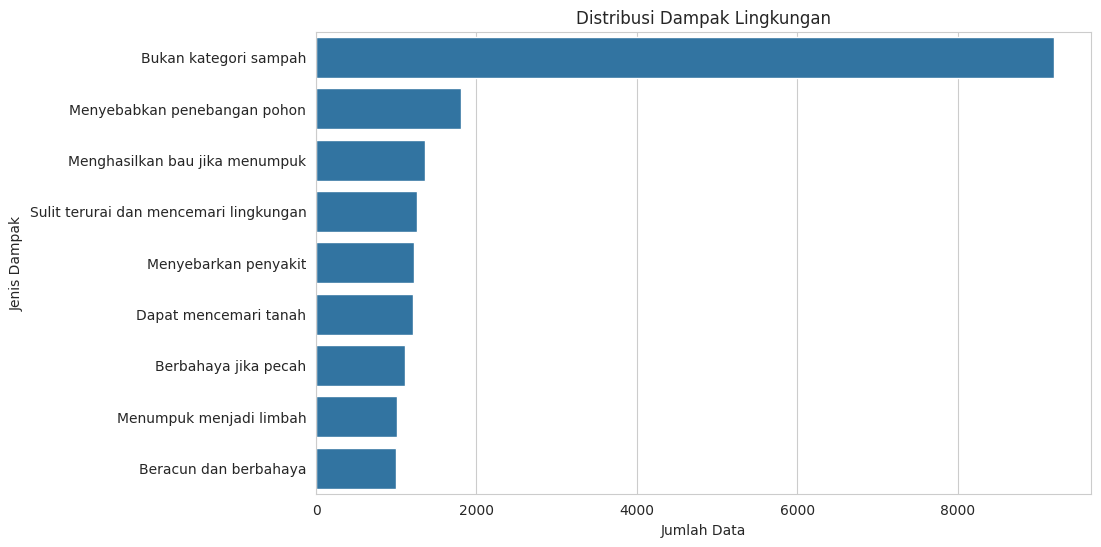

In [21]:
impact_count = eda_df['dampak'].value_counts()

plt.figure(figsize=(10,6))

sns.barplot(
    x=impact_count.values,
    y=impact_count.index
)

plt.title('Distribusi Dampak Lingkungan')
plt.xlabel('Jumlah Data')
plt.ylabel('Jenis Dampak')

plt.show()

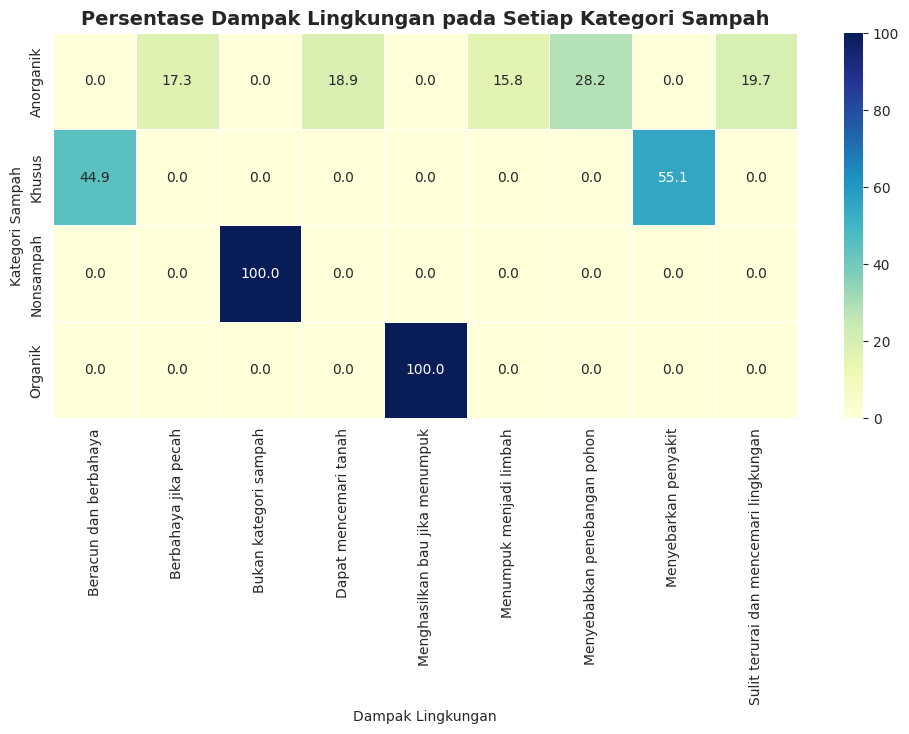

In [22]:
cross_pct = pd.crosstab(
    eda_df['kategori_sampah'],
    eda_df['dampak'],
    normalize='index'
) * 100

plt.figure(figsize=(12,5))

sns.heatmap(
    cross_pct,
    annot=True,
    fmt='.1f',
    cmap='YlGnBu',
    linewidths=0.5
)

plt.title(
    'Persentase Dampak Lingkungan pada Setiap Kategori Sampah',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Dampak Lingkungan')
plt.ylabel('Kategori Sampah')

plt.show()

**Insight:**

- Dampak lingkungan yang paling dominan dalam dataset adalah "Bukan kategori sampah" sebanyak 9.200 data, sejalan dengan dominasi kategori nonsampah dalam dataset.
- Pada kategori sampah organik, seluruh data memiliki dampak berupa menghasilkan bau jika menumpuk, yang menunjukkan pentingnya pengelolaan sampah organik secara cepat dan tepat.
- Kategori sampah khusus (B3 dan medis) memiliki dampak yang lebih serius, yaitu beracun dan berbahaya serta menyebabkan penyakit, sehingga memerlukan perhatian khusus dalam proses pengelolaannya.
- Sampah anorganik memiliki variasi dampak lingkungan yang lebih beragam, seperti pencemaran tanah, sulit terurai, penumpukan limbah, hingga penebangan pohon pada kategori kertas.

**Jawaban Pertanyaan Bisnis**

Berdasarkan hasil analisis, dampak lingkungan pada setiap kategori sampah memiliki karakteristik yang berbeda. Sampah khusus seperti B3 dan medis memiliki risiko paling tinggi terhadap kesehatan dan lingkungan, sedangkan sampah anorganik cenderung memberikan dampak jangka panjang berupa pencemaran dan akumulasi limbah. Oleh karena itu, identifikasi jenis sampah menjadi langkah penting untuk menentukan tindakan pengelolaan yang sesuai

**Pertanyaan 2**

**Bagaimana distribusi metode penanganan pada setiap kategori sampah dan kategori mana yang paling memerlukan pengelolaan khusus?**

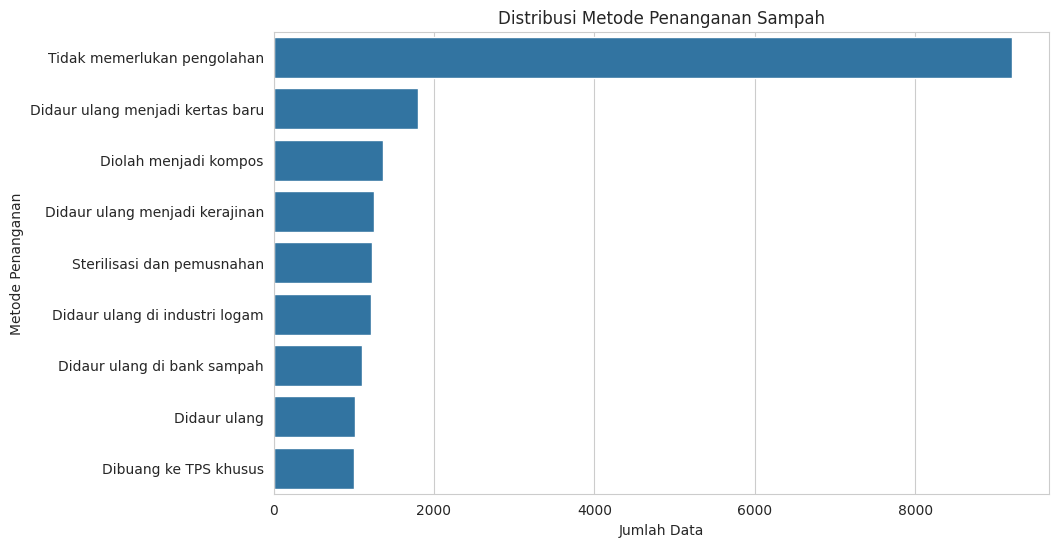

In [23]:
handling_count = eda_df['penanganan'].value_counts()

plt.figure(figsize=(10,6))

sns.barplot(
    x=handling_count.values,
    y=handling_count.index
)

plt.title('Distribusi Metode Penanganan Sampah')
plt.xlabel('Jumlah Data')
plt.ylabel('Metode Penanganan')

plt.show()

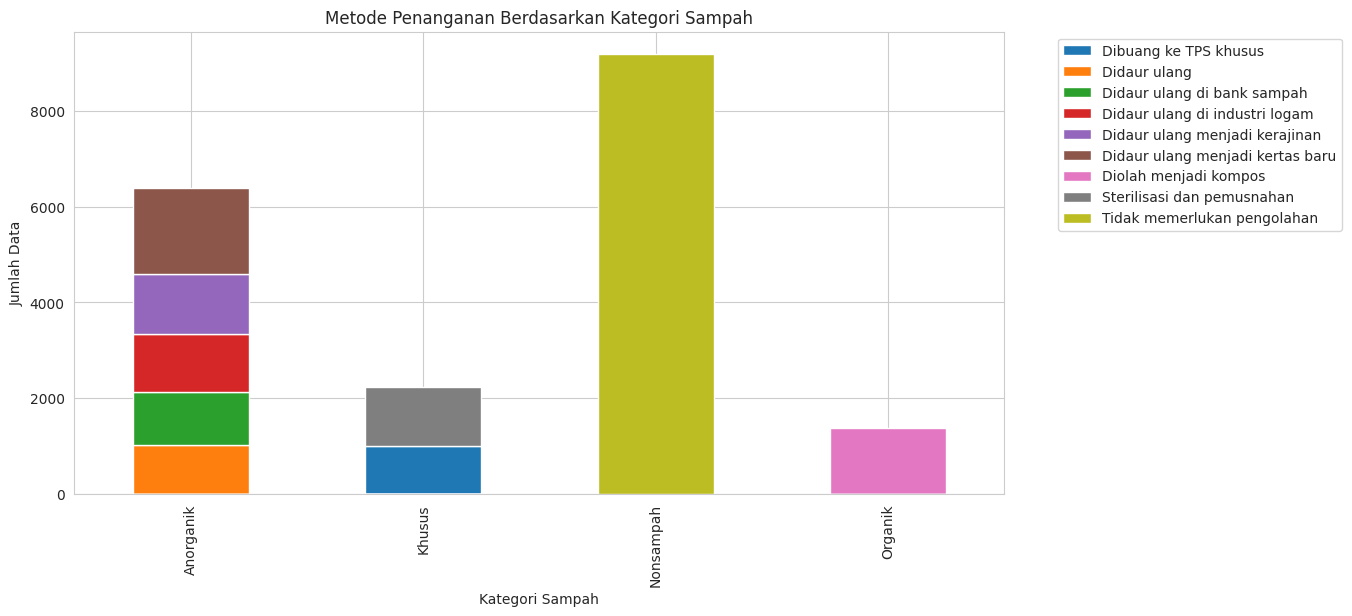

In [24]:
cross = pd.crosstab(
    eda_df['kategori_sampah'],
    eda_df['penanganan']
)

cross.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6)
)

plt.title('Metode Penanganan Berdasarkan Kategori Sampah')
plt.xlabel('Kategori Sampah')
plt.ylabel('Jumlah Data')

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.show()

**Insight:**

- Metode penanganan yang paling dominan adalah tidak memerlukan pengolahan, karena kategori nonsampah merupakan kategori dengan jumlah data terbesar.
- Sampah organik seluruhnya ditangani melalui proses pengolahan menjadi kompos.
- Sampah anorganik didominasi oleh berbagai metode daur ulang, seperti daur ulang menjadi kerajinan, bahan baku baru, maupun produk lainnya.
- Kategori sampah khusus memiliki metode penanganan yang berbeda dibanding kategori lain, yaitu sterilisasi dan pemusnahan untuk sampah medis serta pengolahan limbah B3 khusus untuk sampah B3.

**Jawaban Pertanyaan Bisnis**

Hasil analisis menunjukkan bahwa kategori sampah khusus merupakan kategori yang paling memerlukan pengelolaan khusus karena membutuhkan prosedur penanganan yang lebih kompleks dibandingkan kategori lainnya. Oleh sebab itu, sistem REKLE perlu mampu mengidentifikasi kategori B3 dan medis secara akurat agar rekomendasi penanganan yang diberikan sesuai dengan tingkat risikonya.

**Pertanyaan 3**

**Apakah distribusi data pada setiap kategori sampah dalam dataset REKLE sudah cukup representatif dan seimbang untuk mendukung pengembangan model klasifikasi sampah yang optimal?**

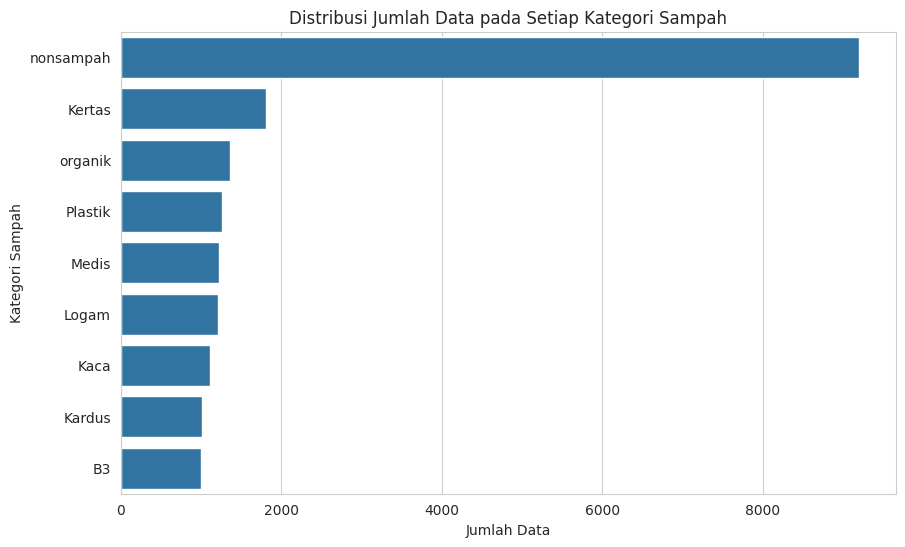

In [25]:
kelas_count = eda_df['kelas'].value_counts()

plt.figure(figsize=(10,6))

sns.barplot(
    x=kelas_count.values,
    y=kelas_count.index
)

plt.title('Distribusi Jumlah Data pada Setiap Kategori Sampah')
plt.xlabel('Jumlah Data')
plt.ylabel('Kategori Sampah')

plt.show()

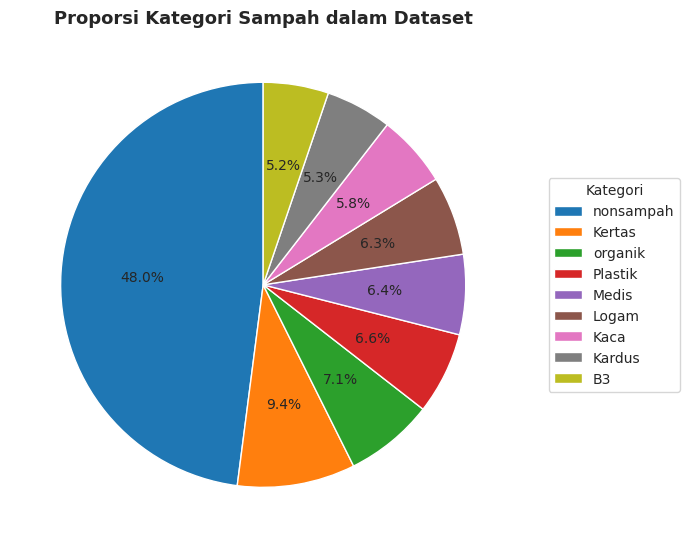

In [26]:
plt.figure(figsize=(7,7))

colors = plt.cm.tab10.colors

plt.pie(
    kelas_count,
    labels=None,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors
)

plt.legend(
    kelas_count.index,
    title='Kategori',
    bbox_to_anchor=(1.05, 0.5),
    loc='center left'
)

plt.title(
    'Proporsi Kategori Sampah dalam Dataset',
    fontsize=13,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

**Insight:**

- Dataset terdiri dari 19.185 data yang tersebar pada sembilan kategori.
- Kategori nonsampah memiliki jumlah data terbesar yaitu 9.200 data atau sekitar 47,95% dari keseluruhan dataset.
- Kategori lainnya memiliki jumlah data yang relatif berdekatan, yaitu berkisar antara 1.000 hingga 1.806 data.
- Seluruh kategori memiliki lebih dari 1.000 data sehingga tetap memiliki representasi yang memadai untuk proses pelatihan model.

**Jawaban Pertanyaan Bisnis**

Distribusi data dalam dataset REKLE dapat dikatakan cukup representatif karena seluruh kategori memiliki jumlah data yang memadai untuk digunakan dalam pelatihan model klasifikasi. Namun, distribusi data belum sepenuhnya seimbang karena kategori nonsampah mendominasi hampir setengah dari total dataset. Oleh karena itu, pada tahap pengembangan model perlu dilakukan evaluasi menggunakan metrik seperti Precision, Recall, dan F1-Score untuk memastikan performa model tetap baik pada seluruh kategori, termasuk kategori dengan jumlah data yang lebih sedikit.

## Analisis Lanjutan (Feature Engineering)

### Tujuan Feature Engineering pada Proyek REKLE

Feature engineering dilakukan dengan menambahkan fitur **risk_level** yang mengelompokkan tingkat risiko lingkungan menjadi **Rendah**, **Sedang**, dan **Tinggi** berdasarkan karakteristik dampak yang dimiliki oleh setiap kategori sampah. Fitur ini bertujuan untuk menyederhanakan interpretasi dampak lingkungan serta mendukung pengembangan sistem rekomendasi pengelolaan sampah yang lebih informatif.


In [33]:
risk_map = {
    'Beracun dan berbahaya': 'Tinggi',
    'Menyebabkan penyakit': 'Tinggi',
    'Sulit terurai dan mencemari lingkungan': 'Sedang',
    'Dapat mencemari tanah': 'Sedang',
    'Menumpuk dan sulit terurai': 'Sedang',
    'Menyebabkan penebangan pohon': 'Sedang',
    'Menghasilkan bau jika menumpuk': 'Rendah',
    'Bukan kategori sampah': 'Rendah'
}

eda_df['risk_level'] = eda_df['dampak'].map(risk_map)

In [35]:
eda_df[['kelas','dampak','risk_level']].head()

,kelas,dampak,risk_level
0,organik,Menghasilkan bau jika menumpuk,Rendah
1,organik,Menghasilkan bau jika menumpuk,Rendah
2,organik,Menghasilkan bau jika menumpuk,Rendah
3,organik,Menghasilkan bau jika menumpuk,Rendah
4,organik,Menghasilkan bau jika menumpuk,Rendah


In [36]:
eda_df['risk_level'].value_counts()

,count
risk_level,
Rendah,10564
Sedang,4273
Tinggi,1000


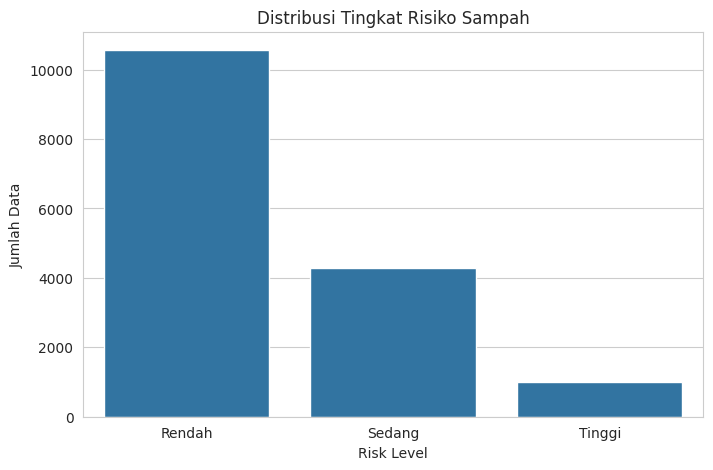

In [37]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=eda_df,
    x='risk_level',
    order=['Rendah','Sedang','Tinggi']
)

plt.title('Distribusi Tingkat Risiko Sampah')
plt.xlabel('Risk Level')
plt.ylabel('Jumlah Data')

plt.show()

**Insight:**

- Sebagian besar data berada pada tingkat risiko rendah karena dominasi kategori nonsampah dan organik.
- Tingkat risiko sedang didominasi oleh sampah anorganik seperti plastik, kaca, logam, kardus, dan kertas.
- Tingkat risiko tinggi berasal dari kategori B3 dan medis yang berpotensi membahayakan kesehatan maupun lingkungan.


### Data Dictionary (Feature Engineering)

| Kolom | Tipe Data | Deskripsi |
|--------|--------|--------|
| risk_level | Object | Tingkat risiko lingkungan yang terdiri dari Rendah, Sedang, dan Tinggi berdasarkan atribut dampak. |

## Conclusion & Recommendation

Berdasarkan hasil analisis, setiap kategori sampah dalam dataset REKLE memiliki karakteristik dampak lingkungan dan metode penanganan yang berbeda. Kategori B3 dan medis merupakan kategori yang memerlukan pengelolaan paling khusus karena memiliki risiko yang lebih tinggi terhadap kesehatan dan lingkungan. Selain itu, meskipun distribusi data belum sepenuhnya seimbang akibat dominasi kategori nonsampah, seluruh kategori tetap memiliki jumlah data yang cukup untuk mendukung pengembangan model klasifikasi sampah berbasis AI. Hasil analisis ini menunjukkan bahwa identifikasi kategori sampah secara akurat sangat penting agar aplikasi REKLE dapat memberikan rekomendasi pengelolaan sampah yang tepat dan berkelanjutan.

**Recommendation**

- Meningkatkan akurasi model klasifikasi pada kategori B3 dan Medis karena kedua kategori tersebut memiliki dampak lingkungan dan risiko kesehatan yang lebih tinggi dibandingkan kategori lainnya.
- Melakukan evaluasi model menggunakan metrik Precision, Recall, dan F1-Score untuk memastikan performa model tetap baik pada seluruh kategori, terutama pada kategori dengan jumlah data yang lebih sedikit.
- Menambah variasi dan jumlah data pada kategori B3, Kardus, dan Kaca guna meningkatkan keseimbangan dataset dan mendukung performa model klasifikasi yang lebih optimal.
- Mengembangkan fitur rekomendasi pengelolaan sampah pada aplikasi REKLE sehingga pengguna tidak hanya memperoleh hasil klasifikasi, tetapi juga mendapatkan saran penanganan yang sesuai dengan kategori sampah yang terdeteksi.
- Memanfaatkan hasil klasifikasi untuk meningkatkan edukasi pengguna mengenai dampak lingkungan dan metode penanganan yang tepat bagi setiap jenis sampah guna mendukung pengelolaan sampah yang lebih berkelanjutan.

In [38]:
# Menyimpan data yang sudah diolah
eda_df.to_csv('rekle_tabular_clean.csv', index=False)
print("Data berhasil disimpan ke rekle_tabular_clean.csv")

Data berhasil disimpan ke rekle_tabular_clean.csv
